In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
uploaded = files.upload()

df = pd.read_csv("Food demand.csv")  # keep filename exact
df.head()

Saving Food demand.csv to Food demand.csv


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1000000,3,157,2760,233.83,231.83,0,0,149
1,1000001,100,104,2956,486.03,583.03,0,0,161
2,1000002,143,75,1971,328.86,327.86,0,0,149
3,1000003,41,24,2539,145.53,145.53,0,0,540
4,1000004,45,83,2539,95.06,120.34,0,0,271


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

df.info()
df.describe()

Shape: (1999, 9)

Columns: ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']

Missing values:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1999 non-null   int64  
 1   week                   1999 non-null   int64  
 2   center_id              1999 non-null   int64  
 3   meal_id                1999 non-null   int64  
 4   checkout_price         1999 non-null   float64
 5   base_price             1999 non-null   float64
 6   emailer_for_promotion  1999 non-null   int

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,1.999000e+03,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,1.001093e+06,75.393197,81.649825,2010.123562,327.302596,347.972866,0.076538,0.105053,258.340170
std,6.323493e+02,41.743802,46.139173,554.686525,150.906902,158.625091,0.265924,0.306698,413.743045
min,1.000000e+06,1.000000,10.000000,1062.000000,65.020000,93.120000,0.000000,0.000000,13.000000
25%,1.000546e+06,40.000000,43.000000,1543.000000,222.645000,242.530000,0.000000,0.000000,55.000000
50%,1.001094e+06,78.000000,76.000000,1971.000000,292.030000,309.430000,0.000000,0.000000,148.000000
75%,1.001638e+06,111.500000,110.000000,2539.000000,435.530000,447.230000,0.000000,0.000000,324.000000
max,1.002181e+06,145.000000,186.000000,2956.000000,767.330000,767.330000,1.000000,1.000000,12137.000000


In [4]:
df_eda = df.copy()

In [5]:
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

if "id" in df_eda.columns:
    df_eda.drop("id", axis=1, inplace=True)

In [6]:
df["discount"] = df["base_price"] - df["checkout_price"]
df["discount_pct"] = (df["base_price"] - df["checkout_price"]) / df["base_price"].replace(0, 1)
df["week_mod_4"] = df["week"] % 4
df["week_mod_12"] = df["week"] % 12

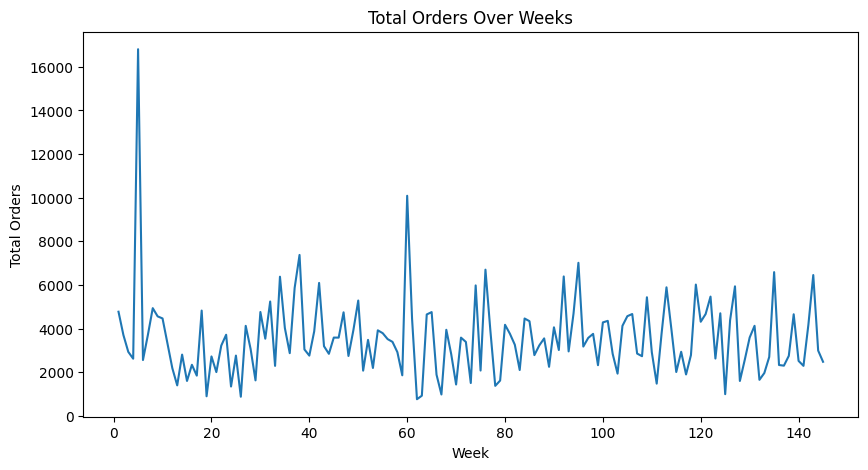

In [7]:
weekly_orders = df_eda.groupby("week")["num_orders"].sum()

plt.figure(figsize=(10, 5))
plt.plot(weekly_orders.index, weekly_orders.values)
plt.title("Total Orders Over Weeks")
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.show()

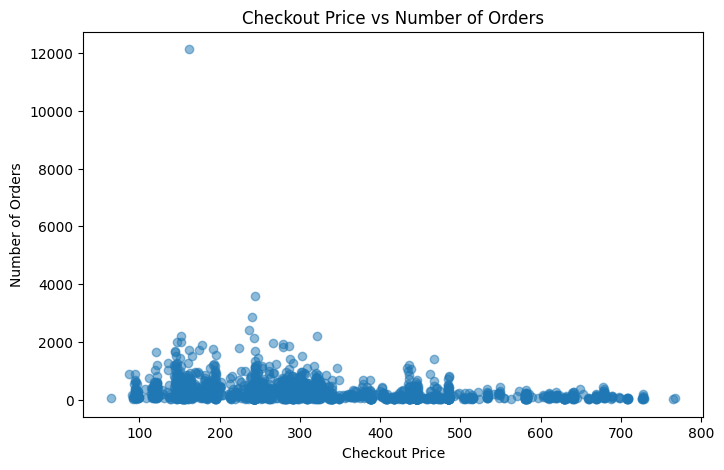

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df_eda["checkout_price"], df_eda["num_orders"], alpha=0.5)
plt.title("Checkout Price vs Number of Orders")
plt.xlabel("Checkout Price")
plt.ylabel("Number of Orders")
plt.show()

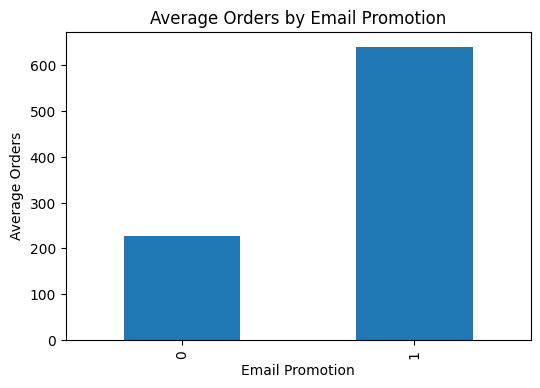

In [9]:
promo_orders = df_eda.groupby("emailer_for_promotion")["num_orders"].mean()

plt.figure(figsize=(6, 4))
promo_orders.plot(kind="bar")
plt.title("Average Orders by Email Promotion")
plt.xlabel("Email Promotion")
plt.ylabel("Average Orders")
plt.show()

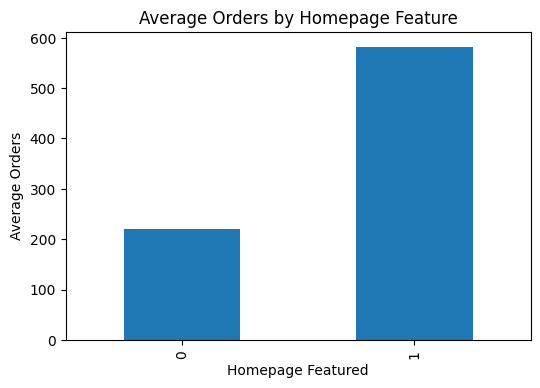

In [10]:
home_orders = df_eda.groupby("homepage_featured")["num_orders"].mean()

plt.figure(figsize=(6, 4))
home_orders.plot(kind="bar")
plt.title("Average Orders by Homepage Feature")
plt.xlabel("Homepage Featured")
plt.ylabel("Average Orders")
plt.show()

In [11]:
promo_impact = df_eda.groupby("emailer_for_promotion")["num_orders"].mean()
increase = ((promo_impact[1] - promo_impact[0]) / promo_impact[0]) * 100

print("Promotion increases orders by:", round(increase, 2), "%")

Promotion increases orders by: 182.85 %


checkout_price
(64.318, 205.482]     380.970526
(205.482, 345.944]    290.854988
(345.944, 486.406]    147.570707
(486.406, 626.868]    110.148148
(626.868, 767.33]      87.297710
Name: num_orders, dtype: float64


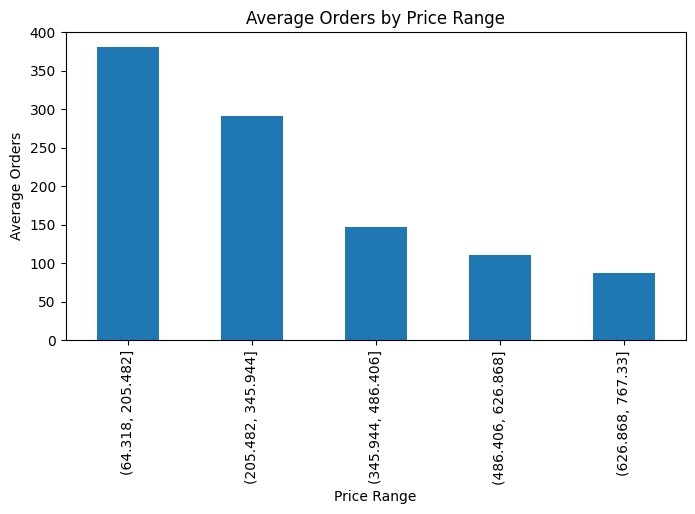

In [12]:
price_bins = pd.cut(df_eda["checkout_price"], bins=5)
price_analysis = df_eda.groupby(price_bins, observed=False)["num_orders"].mean()

print(price_analysis)

price_analysis.plot(kind="bar", figsize=(8, 4))
plt.title("Average Orders by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Orders")
plt.show()

In [13]:
top_meals = df_eda.groupby("meal_id")["num_orders"].mean().sort_values(ascending=False).head(10)

print("Top 10 Meals for Promotion:")
print(top_meals)

Top 10 Meals for Promotion:
meal_id
2290    974.818182
1993    611.434783
1885    578.054545
1754    562.448980
1109    475.064516
1971    449.226415
2826    436.740741
1727    424.816327
2664    417.258065
1062    407.553191
Name: num_orders, dtype: float64


In [14]:
X = df.drop("num_orders", axis=1)
y = df["num_orders"]

X = pd.get_dummies(X, columns=["center_id", "meal_id"], drop_first=True)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)
rf_pred = rf_model.predict(X_test_rf)

In [16]:
rf_mae = mean_absolute_error(y_test_rf, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))
rf_r2 = r2_score(y_test_rf, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 140.08415000000002
RMSE: 245.69342079917402
R2 Score: 0.3341986852446591


In [21]:
from sklearn.linear_model import LinearRegression

# Linear Regression (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train_rf, y_train_rf)

lr_pred = lr_model.predict(X_test_rf)

lr_mae = mean_absolute_error(y_test_rf, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test_rf, lr_pred))
lr_r2 = r2_score(y_test_rf, lr_pred)

print("\n--- Linear Regression (Baseline) ---")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)


# Random Forest (Final)
print("\n--- Random Forest (Final Model) ---")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)


--- Linear Regression (Baseline) ---
MAE: 154.03017530657647
RMSE: 224.59356466800406
R2: 0.44364472432612245

--- Random Forest (Final Model) ---
MAE: 140.08415000000002
RMSE: 245.69342079917402
R2: 0.3341986852446591


In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

results = []

def evaluate_model(name, model):
    model.fit(X_train_rf, y_train_rf)
    pred = model.predict(X_test_rf)

    mae = mean_absolute_error(y_test_rf, pred)
    rmse = np.sqrt(mean_squared_error(y_test_rf, pred))
    r2 = r2_score(y_test_rf, pred)

    results.append((name, mae, rmse, r2))

    print(f"\n--- {name} ---")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

# Linear Regression
evaluate_model("Linear Regression", lr_model)

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
evaluate_model("Decision Tree", dt_model)

# Random Forest
evaluate_model("Random Forest", rf_model)

# Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
evaluate_model("Gradient Boosting", gb_model)


--- Linear Regression ---
MAE: 154.03017530657647
RMSE: 224.59356466800406
R2: 0.44364472432612245

--- Decision Tree ---
MAE: 194.3625
RMSE: 664.7395448594885
R2: -3.8737205631024194

--- Random Forest ---
MAE: 140.08415000000002
RMSE: 245.69342079917402
R2: 0.3341986852446591

--- Gradient Boosting ---
MAE: 144.1095292215611
RMSE: 265.1076043340438
R2: 0.2248210611287449


In [23]:
print("\n===== FINAL MODEL COMPARISON =====")
for r in results:
    print(f"{r[0]} -> MAE: {r[1]:.2f}, RMSE: {r[2]:.2f}, R2: {r[3]:.4f}")


===== FINAL MODEL COMPARISON =====
Linear Regression -> MAE: 154.03, RMSE: 224.59, R2: 0.4436
Decision Tree -> MAE: 194.36, RMSE: 664.74, R2: -3.8737
Random Forest -> MAE: 140.08, RMSE: 245.69, R2: 0.3342
Gradient Boosting -> MAE: 144.11, RMSE: 265.11, R2: 0.2248


In [24]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [27]:
X = df.drop("num_orders", axis=1)
y = df["num_orders"]

X = pd.get_dummies(X, columns=["center_id", "meal_id"], drop_first=True)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import numpy as np

results = []

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append(("Linear Regression",
                mean_absolute_error(y_test, lr_pred),
                np.sqrt(mean_squared_error(y_test, lr_pred)),
                r2_score(y_test, lr_pred)))

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append(("Random Forest",
                mean_absolute_error(y_test, rf_pred),
                np.sqrt(mean_squared_error(y_test, rf_pred)),
                r2_score(y_test, rf_pred)))

# 3. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
results.append(("Gradient Boosting",
                mean_absolute_error(y_test, gb_pred),
                np.sqrt(mean_squared_error(y_test, gb_pred)),
                r2_score(y_test, gb_pred)))

# 4. XGBoost
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.append(("XGBoost",
                mean_absolute_error(y_test, xgb_pred),
                np.sqrt(mean_squared_error(y_test, xgb_pred)),
                r2_score(y_test, xgb_pred)))

# 5. LightGBM
lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)
results.append(("LightGBM",
                mean_absolute_error(y_test, lgb_pred),
                np.sqrt(mean_squared_error(y_test, lgb_pred)),
                r2_score(y_test, lgb_pred)))

# 6. CatBoost
cat = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42)
cat.fit(X_train, y_train)
cat_pred = cat.predict(X_test)
results.append(("CatBoost",
                mean_absolute_error(y_test, cat_pred),
                np.sqrt(mean_squared_error(y_test, cat_pred)),
                r2_score(y_test, cat_pred)))

# FINAL PRINT
print("\n===== FINAL MODEL COMPARISON =====")
for r in results:
    print(f"{r[0]} -> MAE: {r[1]:.2f}, RMSE: {r[2]:.2f}, R2: {r[3]:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000757 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 1599, number of used features: 95
[LightGBM] [Info] Start training from score 258.001251
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [30]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(verbose=0, random_state=42)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [200, 300, 500]
}

grid = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_cat = grid.best_estimator_
best_cat_pred = best_cat.predict(X_test)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Tuned CatBoost MAE:", mean_absolute_error(y_test, best_cat_pred))
print("Tuned CatBoost RMSE:", np.sqrt(mean_squared_error(y_test, best_cat_pred)))
print("Tuned CatBoost R2:", r2_score(y_test, best_cat_pred))

Best Params: {'depth': 6, 'iterations': 500, 'learning_rate': 0.1}
Best CV Score: 0.3925469390274276
Tuned CatBoost MAE: 131.58654090533147
Tuned CatBoost RMSE: 214.7220128501464
Tuned CatBoost R2: 0.49147684398735714


In [31]:
df_lag = df.copy()

In [32]:
df_lag = df_lag.sort_values("week")

df_lag["lag_1"] = df_lag["num_orders"].shift(1)
df_lag["lag_2"] = df_lag["num_orders"].shift(2)

df_lag = df_lag.dropna()

In [33]:
train_lag = df_lag[df_lag["week"] <= 120]
test_lag = df_lag[df_lag["week"] > 120]

X_train_lag = train_lag.drop("num_orders", axis=1)
y_train_lag = train_lag["num_orders"]

X_test_lag = test_lag.drop("num_orders", axis=1)
y_test_lag = test_lag["num_orders"]

In [45]:
# ===============================
# OPTIONAL EXPERIMENT: LAG FEATURES (TIME SERIES)
# ===============================
from catboost import CatBoostRegressor

lag_model = CatBoostRegressor(verbose=0)
lag_model.fit(X_train_lag, y_train_lag)

lag_pred = lag_model.predict(X_test_lag)

print("Lag Model R2:", r2_score(y_test_lag, lag_pred))

Lag Model R2: 0.35190762089638983


Top 15 Important Features:
meal_id_2290             11.422991
discount_pct             10.321476
base_price                9.501804
checkout_price            9.082500
week                      6.710749
homepage_featured         6.664441
emailer_for_promotion     6.565130
discount                  5.693742
center_id_99              3.530033
week_mod_4                2.561307
week_mod_12               2.288147
meal_id_1754              2.230494
meal_id_1109              2.058337
meal_id_1885              1.882601
meal_id_1971              1.653898
dtype: float64


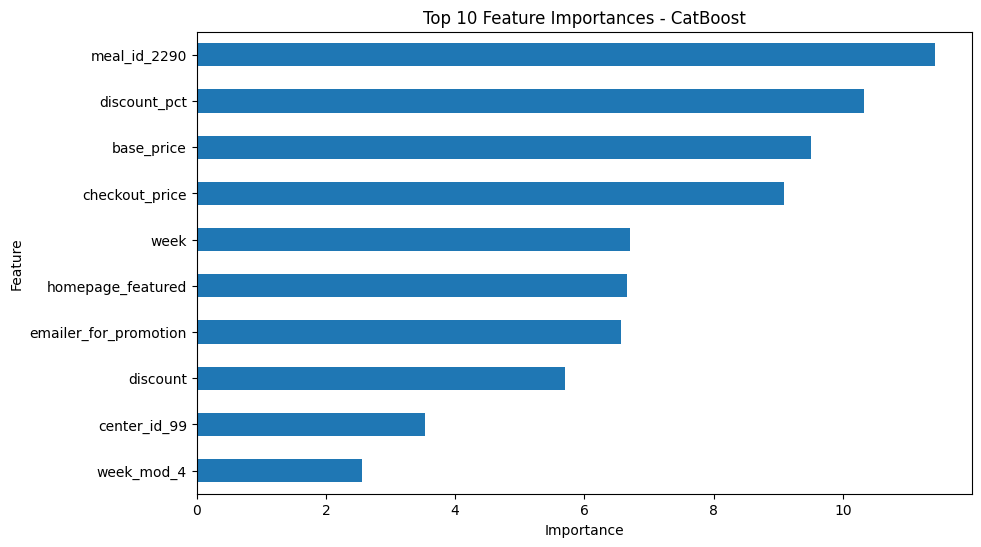

In [36]:
# ===============================
# FEATURE IMPORTANCE
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

cat_feature_importance = pd.Series(best_cat.feature_importances_, index=X_train.columns)
cat_feature_importance = cat_feature_importance.sort_values(ascending=False)

print("Top 15 Important Features:")
print(cat_feature_importance.head(15))

plt.figure(figsize=(10, 6))
cat_feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances - CatBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [37]:
# ===============================
# BUSINESS INSIGHTS
# ===============================
promo_impact = df_eda.groupby("emailer_for_promotion")["num_orders"].mean()
promo_increase = ((promo_impact[1] - promo_impact[0]) / promo_impact[0]) * 100

homepage_impact = df_eda.groupby("homepage_featured")["num_orders"].mean()
homepage_increase = ((homepage_impact[1] - homepage_impact[0]) / homepage_impact[0]) * 100

price_bins = pd.cut(df_eda["checkout_price"], bins=5)
price_analysis = df_eda.groupby(price_bins, observed=False)["num_orders"].mean()

top_meals = df_eda.groupby("meal_id")["num_orders"].mean().sort_values(ascending=False).head(10)

print("📊 BUSINESS INSIGHTS")
print(f"1. Email promotions increase average demand by approximately {promo_increase:.2f}%.")
print(f"2. Homepage featuring increases average demand by approximately {homepage_increase:.2f}%.")
print("3. Lower checkout price ranges generally show higher demand.")
print("4. Certain meals consistently perform better and are strong candidates for promotion.")
print("\nTop 10 Meals for Promotion:")
print(top_meals)

📊 BUSINESS INSIGHTS
1. Email promotions increase average demand by approximately 182.85%.
2. Homepage featuring increases average demand by approximately 164.56%.
3. Lower checkout price ranges generally show higher demand.
4. Certain meals consistently perform better and are strong candidates for promotion.

Top 10 Meals for Promotion:
meal_id
2290    974.818182
1993    611.434783
1885    578.054545
1754    562.448980
1109    475.064516
1971    449.226415
2826    436.740741
1727    424.816327
2664    417.258065
1062    407.553191
Name: num_orders, dtype: float64


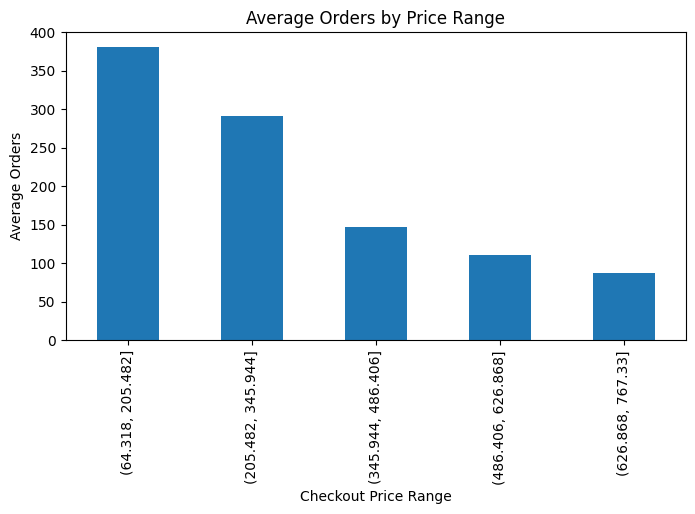

In [38]:
plt.figure(figsize=(8, 4))
price_analysis.plot(kind="bar")
plt.title("Average Orders by Price Range")
plt.xlabel("Checkout Price Range")
plt.ylabel("Average Orders")
plt.show()

In [39]:
# ===============================
# RECOMMENDATION FUNCTION
# ===============================
def recommend_strategy(base_price, checkout_price, promo, homepage, predicted_demand):
    recommendations = []

    discount_pct = (base_price - checkout_price) / base_price if base_price != 0 else 0

    if predicted_demand < 200:
        recommendations.append("Demand is low: avoid overstocking and consider boosting visibility.")

    if discount_pct < 0.15:
        recommendations.append("Increase discount slightly to improve demand.")

    if promo == 0:
        recommendations.append("Enable email promotion to boost customer engagement.")

    if homepage == 0:
        recommendations.append("Feature the item on the homepage for better visibility.")

    if predicted_demand > 500:
        recommendations.append("High demand expected: ensure stock and delivery readiness.")

    if len(recommendations) == 0:
        recommendations.append("Current setup looks reasonable; maintain the strategy.")

    return recommendations

In [42]:
# ===============================
# INTERACTIVE NOTEBOOK DASHBOARD
# ===============================
import ipywidgets as widgets
from IPython.display import display, clear_output

print("🚀 Food Demand Forecasting & Promotion Optimization Dashboard")
print("Adjust parameters and click Predict\n")

price_slider = widgets.IntSlider(value=200, min=50, max=700, step=1, description='Price')
base_slider = widgets.IntSlider(value=250, min=50, max=700, step=1, description='Base')
week_slider = widgets.IntSlider(value=50, min=1, max=145, step=1, description='Week')
promo_toggle = widgets.ToggleButtons(options=[0, 1], description='Promo')
home_toggle = widgets.ToggleButtons(options=[0, 1], description='Homepage')
button = widgets.Button(description="Predict", button_style='success')
output = widgets.Output()
def predict_demand(b):
    with output:
        clear_output()

        # start with a valid encoded row
        sample = X_test.iloc[[0]].copy()

        # update user-controlled numeric features
        sample["checkout_price"] = price_slider.value
        sample["base_price"] = base_slider.value
        sample["emailer_for_promotion"] = promo_toggle.value
        sample["homepage_featured"] = home_toggle.value
        sample["week"] = week_slider.value

        # derived features
        discount = base_slider.value - price_slider.value
        discount_pct = discount / base_slider.value if base_slider.value != 0 else 0
        week_mod_4 = week_slider.value % 4
        week_mod_12 = week_slider.value % 12

        if "discount" in sample.columns:
            sample["discount"] = discount
        if "discount_pct" in sample.columns:
            sample["discount_pct"] = discount_pct
        if "week_mod_4" in sample.columns:
            sample["week_mod_4"] = week_mod_4
        if "week_mod_12" in sample.columns:
            sample["week_mod_12"] = week_mod_12

        pred = best_cat.predict(sample)
        predicted_demand = float(pred[0])

        print(f"📈 Estimated Weekly Demand: {int(predicted_demand)} orders")
        print(f"🤖 Final Model: Tuned CatBoost (R² ≈ 0.49)\n")

        if predicted_demand > 500:
            print("🔥 High demand expected — ensure stock and delivery readiness")
        elif predicted_demand > 200:
            print("📦 Moderate demand — plan inventory accordingly")
        else:
            print("📉 Low demand — avoid overstocking and improve promotions")

        recs = recommend_strategy(
            base_slider.value,
            price_slider.value,
            promo_toggle.value,
            home_toggle.value,
            predicted_demand
        )

        print("\n✅ Recommended Actions:")
        for r in recs:
            print("-", r)

        # Price simulation
        prices = list(range(100, 501, 50))
        preds = []

        for p in prices:
            temp = sample.copy()
            temp["checkout_price"] = p

            temp_discount = base_slider.value - p
            temp_discount_pct = temp_discount / base_slider.value if base_slider.value != 0 else 0

            if "discount" in temp.columns:
                temp["discount"] = temp_discount
            if "discount_pct" in temp.columns:
                temp["discount_pct"] = temp_discount_pct

            preds.append(best_cat.predict(temp)[0])

        plt.figure(figsize=(7, 4))
        plt.plot(prices, preds, marker="o")
        plt.title("Price Simulation: Checkout Price vs Predicted Demand")
        plt.xlabel("Checkout Price")
        plt.ylabel("Predicted Demand")
        plt.show()

button.on_click(predict_demand)

display(price_slider, base_slider, week_slider, promo_toggle, home_toggle, button, output)

🚀 Food Demand Forecasting & Promotion Optimization Dashboard
Adjust parameters and click Predict



IntSlider(value=200, description='Price', max=700, min=50)

IntSlider(value=250, description='Base', max=700, min=50)

IntSlider(value=50, description='Week', max=145, min=1)

ToggleButtons(description='Promo', options=(0, 1), value=0)

ToggleButtons(description='Homepage', options=(0, 1), value=0)

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()